# Decision Tree Forecasting ML

Complete machine learning model for predicting next day maximum temperature using Decision Tree Regressor.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

## Step 1: Load the dataset from CSV

In [2]:
data_path = "../../data/cambodia_weather.csv"
if data_path is None:
    raise FileNotFoundError("Could not find cambodia_weather.csv in expected locations.")

df = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
print(df.head())

Loaded dataset from: ../../data/cambodia_weather.csv
         date  temp_max  temp_min  rain  wind_speed    province    lat     lon
0  2015-01-01      30.1      20.5   0.0        20.0  Phnom Penh  11.55  104.91
1  2015-01-02      30.0      19.9   0.0        18.7  Phnom Penh  11.55  104.91
2  2015-01-03      31.2      22.6   0.0        16.9  Phnom Penh  11.55  104.91
3  2015-01-04      31.5      22.2   0.0         9.4  Phnom Penh  11.55  104.91
4  2015-01-05      32.2      23.6   0.0         9.7  Phnom Penh  11.55  104.91


## Step 2: Convert date column

In [4]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
print(df[["date", "temp_max", "temp_min", "rain", "wind_speed"]].head())

        date  temp_max  temp_min  rain  wind_speed
0 2015-01-01      30.1      20.5   0.0        20.0
1 2015-01-01      24.5      16.1   0.0        29.1
2 2015-01-01      29.0      19.0   0.0        21.3
3 2015-01-01      29.8      23.9   0.3        16.5
4 2015-01-01      29.6      20.1   0.0        13.9


## Step 3: Create target variable

In [5]:
df["temp_max_next"] = df["temp_max"].shift(-1)
print(df[["temp_max", "temp_max_next"]].head())

   temp_max  temp_max_next
0      30.1           24.5
1      24.5           29.0
2      29.0           29.8
3      29.8           29.6
4      29.6           24.0


## Step 4: Create lag features

In [6]:
df["temp_max_lag1"] = df["temp_max"].shift(1)
df["rain_lag1"] = df["rain"].shift(1)
df = df.dropna().reset_index(drop=True)
print(df[["temp_max_lag1", "temp_min", "rain_lag1", "wind_speed", "temp_max_next"]].head())

   temp_max_lag1  temp_min  rain_lag1  wind_speed  temp_max_next
0           30.1      16.1        0.0        29.1           29.0
1           24.5      19.0        0.0        21.3           29.8
2           29.0      23.9        0.0        16.5           29.6
3           29.8      20.1        0.3        13.9           24.0
4           29.6      15.9        0.0        27.7           29.7


## Step 5: Features and target

In [7]:
feature_columns = ["temp_max_lag1", "temp_min", "rain_lag1", "wind_speed"]
X = df[feature_columns]
y = df["temp_max_next"]
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20538, 4)
Target shape: (20538,)


## Step 6: Train and test split

In [8]:
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 16430
Test size: 4108


## Step 7: Train Decision Tree model

In [9]:
model = DecisionTreeRegressor(max_depth=15, random_state=42)
model.fit(X_train, y_train)
model

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

## Step 8: Predictions

In [10]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[30.18799582 30.46507937 27.56666667 28.74285714 33.85       30.18799582
 30.18799582 29.92805755 29.80531401 29.90526316]


## Step 9: Evaluation

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

baseline_pred = X_test["temp_max_lag1"].values
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")
print(f"Baseline RMSE (carry-forward): {baseline_rmse:.2f}")

results = pd.DataFrame({
    "date": df.loc[X_test.index, "date"].values,
    "actual_temp_max_next": y_test.values,
    "pred_temp_max_next": y_pred,
    "abs_error": np.abs(y_test.values - y_pred),
})
results.tail(10)

MAE: 2.60
RMSE: 3.34
R2: -0.2356
Baseline RMSE (carry-forward): 3.48


,date,actual_temp_max_next,pred_temp_max_next,abs_error
4098,2026-03-29,34.5,26.000000,8.500000
4099,2026-03-30,31.2,28.950000,2.250000
4100,2026-03-30,37.9,31.496552,6.403448
4101,2026-03-30,32.2,30.100000,2.100000
4102,2026-03-30,35.5,34.900000,0.600000
4103,2026-03-30,31.3,26.500000,4.800000
4104,2026-03-31,35.2,32.390476,2.809524
4105,2026-03-31,35.7,34.000000,1.700000
4106,2026-03-31,38.2,30.100000,8.100000
4107,2026-03-31,30.4,39.400000,9.000000


## Step 10: Visualization

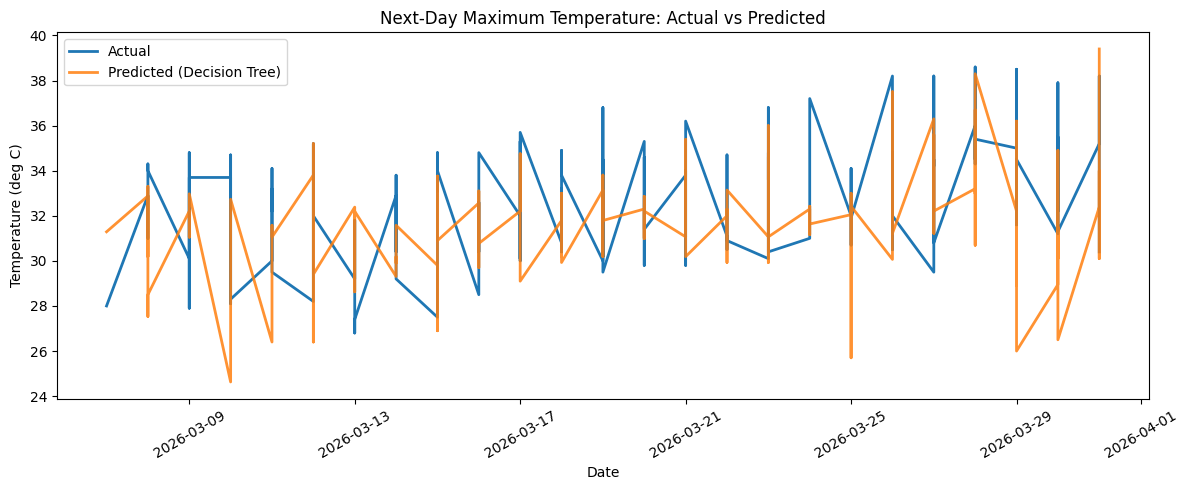

In [13]:
plot_n = min(120, len(results))

plt.figure(figsize=(12, 5))
plt.plot(results["date"].iloc[-plot_n:], results["actual_temp_max_next"].iloc[-plot_n:], label="Actual", linewidth=2)
plt.plot(results["date"].iloc[-plot_n:], results["pred_temp_max_next"].iloc[-plot_n:], label="Predicted (Decision Tree)", linewidth=2, alpha=0.85)
plt.title("Next-Day Maximum Temperature: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Temperature (deg C)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()